In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [14]:
df = pd.read_csv("Salary Data.csv")

In [15]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [16]:
x = df["YearsExperience"].values
y = df["Salary"].values

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

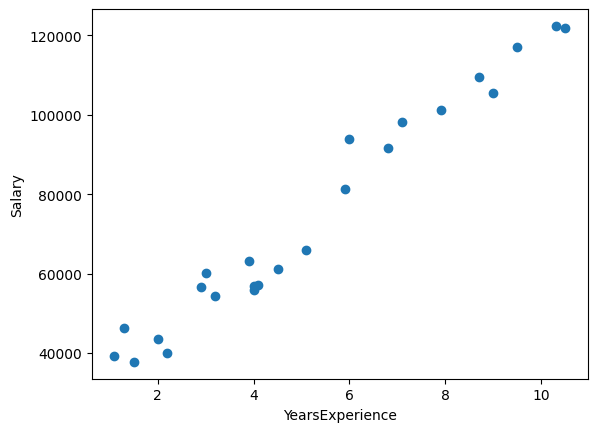

In [18]:
plt.scatter(x_train, y_train)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

In [19]:
def cost_function(x, y, w, b):
    m = len(x)
    cost_sum = 0

    for i in range(m):
        f = w * x[i] + b
        cost = (f - y[i]) ** 2
        cost_sum += cost

    total_cost = (1/(2*m)) * cost_sum
    return total_cost

In [20]:
def gradient_function(x, y, w, b):
    m = len(x)
    dc_dw = 0
    dc_db = 0

    for i in range(m):
        f = w * x[i] + b

        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])

    dc_dw = (1/m) * dc_dw
    dc_db = (1/m) * dc_db

    return dc_dw, dc_db

In [21]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0
    cost_history = []

    for i in range(iterations):
        dc_dw, dc_db = gradient_function(x, y, w, b)

        w = w - alpha * dc_dw
        b = b - alpha * dc_db

        cost_history.append(cost_function(x, y, w, b))

    return w, b, cost_history

In [22]:
learning_rate = 0.01
iterations = 10000

final_w, final_b, cost_history = gradient_descent(
    x_train, y_train, learning_rate, iterations
)

print(f"w: {final_w:.4f}")
print(f"b: {final_b:.4f}")

print(f"w: {final_w:.4f}, b: {final_b:.4f}")

w: 9423.8153
b: 25321.5830
w: 9423.8153, b: 25321.5830


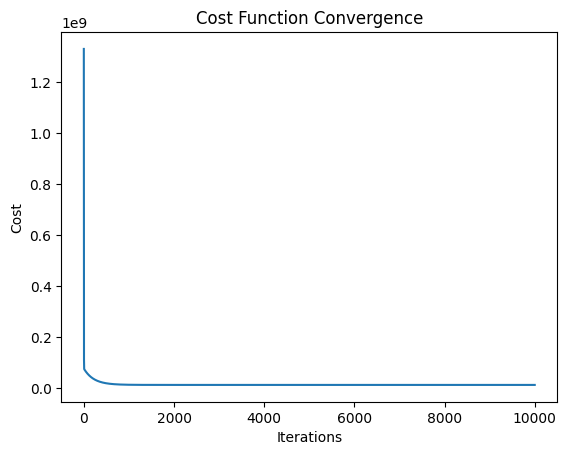

In [23]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

In [24]:
y_pred = final_w * x_test + final_b

mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 6286.45
RMSE : 7059.04
R²   : 0.9024


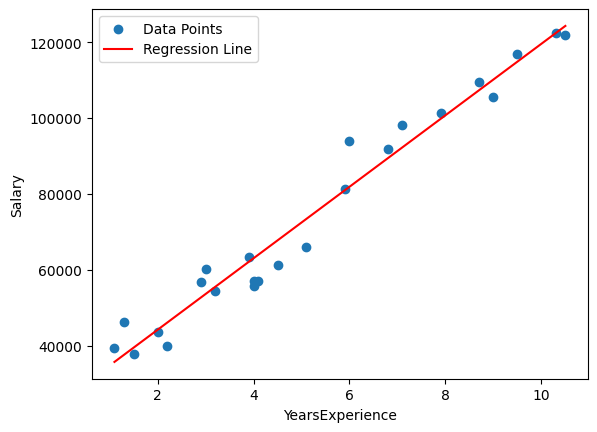

In [12]:
plt.scatter(x_train, y_train, label='Data Points')

x_vals = np.linspace(min(x_train), max(x_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label='Regression Line')

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.show()

Using libraries

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
lr = LinearRegression()

In [28]:
lr.fit(x_train.reshape(-1,1),y_train)

LinearRegression()

In [29]:
y_pred_lr = lr.predict(x_test.reshape(-1, 1))

In [31]:
#evalution

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [33]:
print("Scikit-learn Linear Regression")
print(f"Slope (w): {lr.coef_[0]:.4f}")
print(f"Intercept (b): {lr.intercept_:.4f}")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²: {r2_lr:.4f}")

Scikit-learn Linear Regression
Slope (w): 9423.8153
Intercept (b): 25321.5830
MAE: 6286.45
RMSE: 7059.04
R²: 0.9024
